No data for P=150 and T=10000
No data for P=150 and T=11000
No data for P=150 and T=12000
No data for P=200 and T=11000
No data for P=200 and T=12000
No data for P=400 and T=11000
No data for P=600 and T=10000
No data for P=600 and T=11000
No data for P=600 and T=12000
No data for P=800 and T=12000


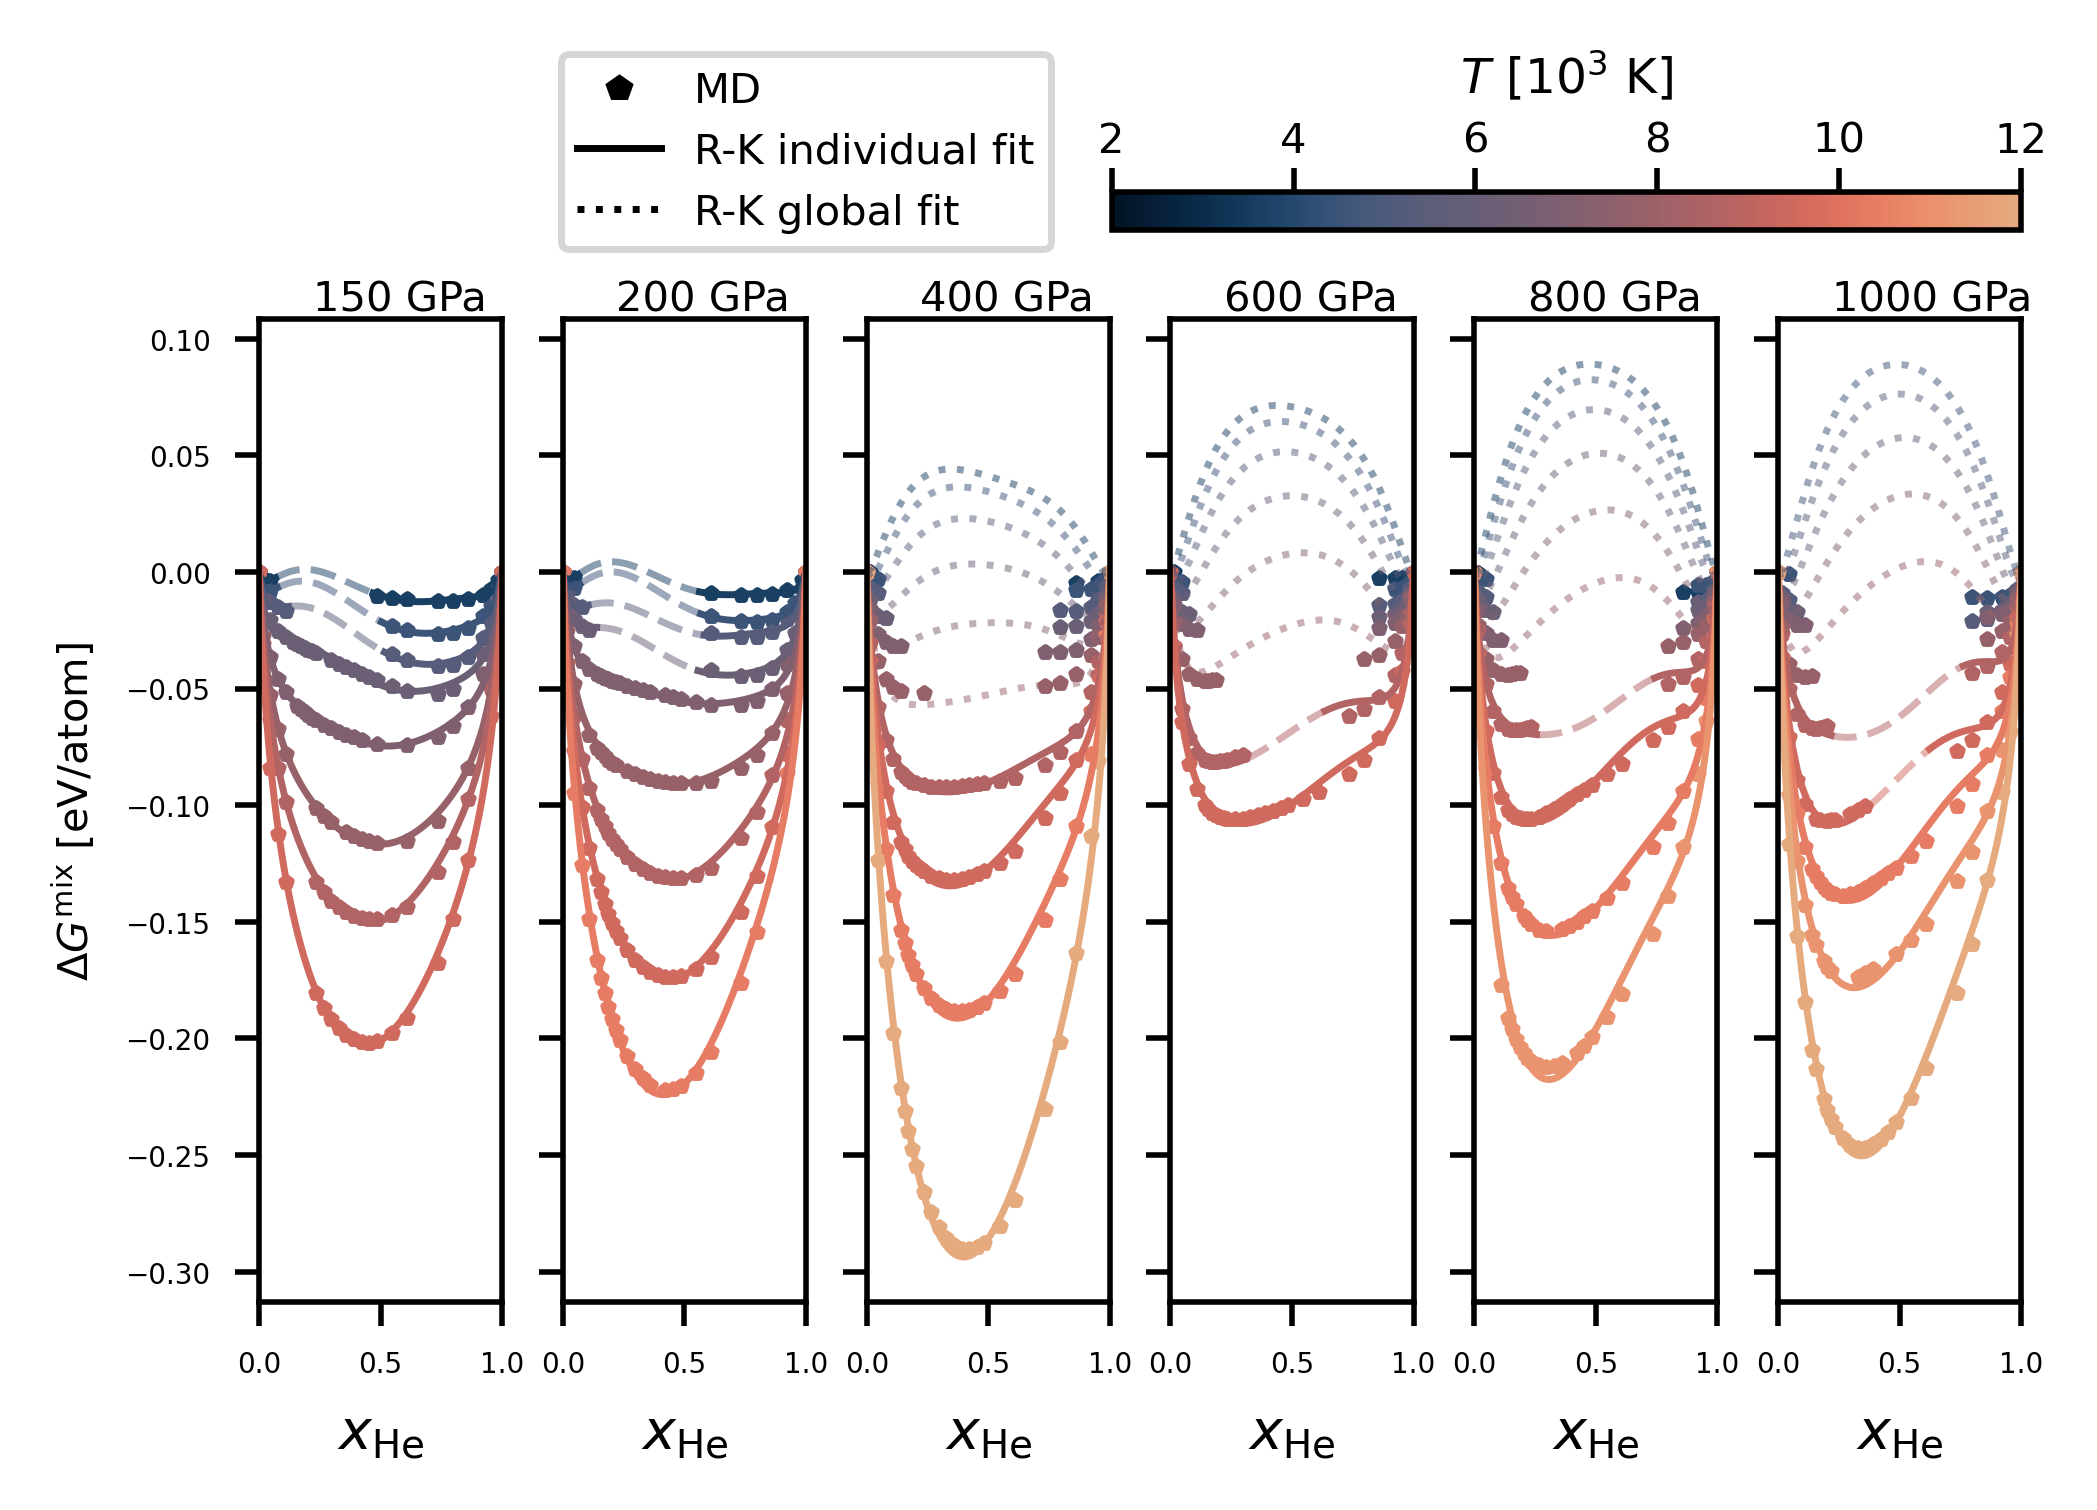

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.cm as cm
import h5py
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

# --- Model functions for omega1, omega2, omega3 ---
def omega1_model(T, P):
    # T in K, P in GPa
    # Model: w(T, P) = a0 + b1*T + b2*T^2 + c1*P + c2*P^2
    # a0 = -0.230428 ± 0.026, b1 = 0.272684 ± 0.0077, b2 = -0.0120829 ± 0.00067,
    # c1 = 0.116921 ± 0.012, c2 = -0.00575461 ± 0.0011
    # T and P must be rescaled: T/1000, P/100
    t = T / 1000
    p = P / 100
    a0 = -0.230428
    b1 = 0.272684
    b2 = -0.0120829
    c1 = 0.116921
    c2 = -0.00575461
    return a0 + b1 * t + b2 * t**2 + c1 * p + c2 * p**2

def omega2_model(T, P):
    # Model: w(T, P) = a0 + b1*T + b2*T^2 + c1*P + c2*P^2
    # a0 = 0.111668 ± 0.028, b1 = 0.0180989 ± 0.008, b2 = -0.00436409 ± 0.00063,
    # c1 = -0.0212551 ± 0.0094, c2 = 0.000976806 ± 0.00084
    t = T / 1000
    p = P / 100
    a0 = 0.111668
    b1 = 0.0180989
    b2 = -0.00436409
    c1 = -0.0212551
    c2 = 0.000976806
    return a0 + b1 * t + b2 * t**2 + c1 * p + c2 * p**2

def omega3_model(P):
    # Model: w(P) = a0 + c1*P
    # a0 = 0.244669 ± 0.0099, c1 = 0.0052039 ± 0.0028
    p = P / 100
    a0 = 0.244669
    c1 = 0.0052039
    return a0 + c1 * p

# --- G_mix model ---
kbK_2_ev = 8.617333262145e-5
def regular_sol_third_order(x, omega, omega_2nd, omega_3rd, T):
    epsilon = 1e-10  
    x = np.clip(x, epsilon, 1 - epsilon)
    return (x * np.log(x) + (1-x) * np.log(1-x)) * kbK_2_ev * T + omega * x * (1-x) + omega_2nd * x * (1-x)* (1-2*x) + omega_3rd * x * (1 - x) * (1 - 2 * x) ** 2


Phase_sep_data_VDW_FULL = np.array([
    [150, 1000, 0.094, 0.546],
    [150, 2000, 0.067, 0.469],
    [150, 3000, 0.075, 0.504],
    [150, 4000, 0.121, 0.516],

    [200, 2000, 0.063, 0.562],
    [200, 3000, 0.069, 0.567],
    [200, 4000, 0.104, 0.581],
    [200, 5000, 0.139, 0.556],

    [400, 2000, 0.034, 0.805],
    [400, 3000, 0.072, 0.804],
    [400, 4000, 0.071, 0.758],
    [400, 5000, 0.107, 0.754],
    [400, 6000, 0.153, 0.698],
    [400, 7000, 0.256, 0.602],

    [600, 2000, 0.034, 0.824],
    [600, 3000, 0.067, 0.865],
    [600, 4000, 0.095, 0.808],
    [600, 5000, 0.106, 0.806],
    [600, 6000, 0.133, 0.800],
    [600, 7000, 0.189, 0.746],
    [600, 8000, 0.308, 0.635],
    [800, 2000, 0.035, 0.803],
    [800, 3000, 0.062, 0.886],
    [800, 4000, 0.072, 0.864],
    [800, 5000, 0.102, 0.861],
    [800, 6000, 0.137, 0.807],
    [800, 7000, 0.190, 0.770],
    [800, 8000, 0.256, 0.742],

    [1000, 2000, 0.040, 0.735],
    [1000, 3000, 0.072, 0.641],
    [1000, 4000, 0.076, 0.738],
    [1000, 5000, 0.106, 0.808],
    [1000, 6000, 0.135, 0.811],
    [1000, 7000, 0.153, 0.805],
    [1000, 8000, 0.218, 0.762],
    [1000, 9000, 0.375, 0.623]
])


def extract_omega_data_at_pressure(dataset, pressure):
    """Extract omega data at a specified pressure from the dataset."""
    mask = dataset[:, 0] == pressure
    P_data = dataset[mask, 0]
    T_data = dataset[mask, 1]
    omega_data_1st = dataset[mask, 2]
    omega_data_1st_error = dataset[mask, 3]
    omega_data_2nd = dataset[mask, 4]
    omega_data_2nd_error = dataset[mask, 5]
    omega_data_3rd = dataset[mask, 6]
    omega_data_3rd_error = dataset[mask, 7]
    
    return P_data, T_data, omega_data_1st, omega_data_1st_error, omega_data_2nd, omega_data_2nd_error, omega_data_3rd, omega_data_3rd_error
def read_data(file_path, P, T):
    with h5py.File(file_path, 'r') as hf:
        try:
            group = hf[f'P_{P}/T_{T}']
            data = {
                'xa': np.array(group['xa']),
                'xb': np.array(group['xb']),
                'saa': np.array(group['saa']),
                'sab': np.array(group['sab']),
                'sbb': np.array(group['sbb']),
                'mu_He_GH': np.array(group['mu_He_GH']),
                'mu_H_GH': np.array(group['mu_H_GH'])
            }
            return data
        except KeyError:
            print(f"No data for P={P} and T={T}")
            return None
        
def ideal(x, T):
    epsilon = 1e-10  
    x = np.clip(x, epsilon, 1 - epsilon)
    return (x * np.log(x) + (1-x) * np.log(1-x)) * kbK_2_ev * T 

def regular_sol_third_order(x, omega, omega_2nd, omega_3rd, T):
    epsilon = 1e-10  
    x = np.clip(x, epsilon, 1 - epsilon)
    return (x * np.log(x) + (1-x) * np.log(1-x)) * kbK_2_ev * T + omega * x * (1-x) + omega_2nd * x * (1-x)* (1-2*x) + omega_3rd * x * (1 - x) * (1 - 2 * x) ** 2

def regular_sol_third_order_second_derivative(x, omega, omega_2nd, omega_3rd, T):
    epsilon = 1e-10
    x = np.clip(x, epsilon, 1 - epsilon)
    return  kbK_2_ev * T / (x * (1-x)) - 2 * omega + 6 * omega_2nd * (2*x - 1) + omega_3rd * (-10 + 48*x - 48*x**2)
    

font = {'family': 'serif', 'size': 8}
plt.rc('font', **font)
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['axes.titlesize'] = 8
matplotlib.rcParams['axes.labelsize'] = 8
matplotlib.rcParams['xtick.labelsize'] = 4
matplotlib.rcParams['ytick.labelsize'] = 4
matplotlib.rcParams['legend.fontsize'] = 7

# Load custom colormap
cm_data = np.loadtxt("./backup_data/lipari.txt")
cmap = LinearSegmentedColormap.from_list('lipari', cm_data)
new_colors = cmap(np.linspace(0.0, 0.8, 256))  # Truncate colormap
truncated_cmap = ListedColormap(new_colors)



# Define constants and parameters
T_list = [2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000]
P_list = [150, 200, 400, 600, 800, 1000]
kbK_2_ev = 8.617333262145e-5

# Phase-separation data


def regular_sol_third_order(x, omega, omega_2nd, omega_3rd, T):
    epsilon = 1e-10  
    x = np.clip(x, epsilon, 1 - epsilon)
    return (x * np.log(x) + (1-x) * np.log(1-x)) * kbK_2_ev * T + omega * x * (1-x) + omega_2nd * x * (1-x)* (1-2*x) + omega_3rd * x * (1 - x) * (1 - 2 * x) ** 2

colors = cm.viridis(np.linspace(0, 1, len(T_list)))
omega_fitted_dataset = []

# Set figure size: ~1/4 A4 width and compact height for subplots
A4_width_mm = 210  # A4 width (mm)
fig_width_mm = A4_width_mm * 0.55  
fig_height_mm = 32.4 * 2

# Convert mm to inches (1 inch = 25.4 mm)
fig_width_inches = fig_width_mm / 25.4
fig_height_inches = fig_height_mm / 25.4

fig, allax = plt.subplots(nrows=1, ncols=len(P_list), 
                          figsize=(fig_width_inches, fig_height_inches), 
                          sharex=False, sharey=True, dpi=500)
plt.subplots_adjust(wspace=0.25, hspace=0.07)

for i, P in enumerate(P_list):
    ax = allax[i]
    has_run = False 
    for j, T in enumerate(T_list):




        if P == 1000 and T == 2000:
            continue

        # 
        cmap = plt.get_cmap('afmhot_r')
        norm = plt.Normalize(0, max(T_list)/1000)
        sm = cm.ScalarMappable(cmap=truncated_cmap, norm=norm)
        sm.set_array([])

        
        color = sm.to_rgba(T/1000)

        fit_auto_RK_model = True

        if P == 400 and T in [2000, 3000, 4000, 5000, 6000, 7000]:
            fit_auto_RK_model = False
        
        if P == 600 and T in [2000, 3000, 4000, 5000, 6000, 7000]:
            fit_auto_RK_model = False

        if P == 800 and T in [2000, 3000, 4000, 5000, 6000, 7000]:
            fit_auto_RK_model = False

        if P == 1000 and T in [3000, 4000, 5000, 6000, 7000]:
            fit_auto_RK_model = False
        


        try:
            data = read_data('./backup_data/vdW-DF_chemical_potential_results.h5', P, T)

            mu_He_GH = data['mu_He_GH']
            mu_H_GH = data['mu_H_GH']

            xa_now = mu_He_GH[:,0]
            G_mix_real = mu_He_GH[:,1] * mu_He_GH[:,0] + mu_H_GH[:,1] * mu_H_GH[:,0]

            xa_now = np.insert(xa_now, 0, 1)
            xa_now = np.append(xa_now, 0) 

            G_mix_real = np.insert(G_mix_real, 0, 0)
            G_mix_real = np.append(G_mix_real, 0) 

            xr = np.linspace(0,1,100) 
            
            #ax.errorbar(xa_now, G_mix_real, yerr=0,
            #            marker='p', label=f'{T}')
        
            if T in Phase_sep_data_VDW_FULL[Phase_sep_data_VDW_FULL[:, 0] == P][:, 1]:

                indices = np.where(Phase_sep_data_VDW_FULL[Phase_sep_data_VDW_FULL[:, 0] == P][:,1] == T)[0]
                left_boundary = Phase_sep_data_VDW_FULL[Phase_sep_data_VDW_FULL[:, 0] == P][indices, 2][0]
                right_He_boundary = Phase_sep_data_VDW_FULL[Phase_sep_data_VDW_FULL[:, 0] == P][indices, 3][0]
                min_index = np.argmin(G_mix_real)
                right_boundary = xa_now[min_index]

                mask = (xa_now >= left_boundary)  & (xa_now <= right_He_boundary)  
            

                #& (xa_now <= right_boundary)
                inverted_mask = ~mask
                
                xa_now_filtered = xa_now[inverted_mask]
                
                G_mix_real_filtered = G_mix_real[inverted_mask]
                
                popt, pcov = curve_fit(lambda x, omega, omega_2nd, omega_3rd: regular_sol_third_order(x, omega, omega_2nd,omega_3rd, T), xa_now_filtered, G_mix_real_filtered)
                omega_1st_fitted, omega_2nd_fitted, omega_3rd_fitted = popt
                perr = np.sqrt(np.diag(pcov))
                omega_1st_error, omega_2nd_error, omega_3rd_error = perr


                ax.scatter(xa_now_filtered, G_mix_real_filtered, color=color, marker='p', ls="-", s=2, lw=1)

                x_fit_left = np.linspace(0, left_boundary, 20)             
                y_fit_left = regular_sol_third_order(x_fit_left, omega_1st_fitted, omega_2nd_fitted, omega_3rd_fitted, T)
                

                x_fit_right = np.linspace(right_He_boundary, 1.0, 20)             
                y_fit_right = regular_sol_third_order(x_fit_right, omega_1st_fitted, omega_2nd_fitted, omega_3rd_fitted, T)



                x_demix = np.linspace(x_fit_left[-1], x_fit_right[0], 50)    
                y_demix = regular_sol_third_order(x_demix, omega_1st_fitted, omega_2nd_fitted, omega_3rd_fitted, T)

                if fit_auto_RK_model == True:
                    ax.plot(x_fit_left, y_fit_left, color=color, ls="-", lw=1)
                    ax.plot(x_fit_right, y_fit_right, color=color, ls="-", lw=1)
                    ax.plot(x_demix, y_demix, color=color, ls="--", lw=1, alpha = 0.5)

                    omega_fitted_dataset.append([P, T, omega_1st_fitted, omega_1st_error, omega_2nd_fitted, omega_2nd_error, omega_3rd_fitted, omega_3rd_error])
                else:
                    omega1 = omega1_model(T, P)
                    omega2 = omega2_model(T, P)
                    omega3 = omega3_model(P)

                    # Plot model G_mix as dashed line
                    x_fit = np.linspace(0, 1, 50) 
                    #x_fit = np.linspace(x_fit_left[-1], x_fit_right[0]+0.1, 50) 
                    y_fit = regular_sol_third_order(x_fit, omega1, omega2, omega3, T)
                    ax.plot(x_fit, y_fit, color=color, ls="dotted", lw=1, alpha=0.5, label=None)
                


                #if fit_auto_RK_model == False:
                #    ax.plot(x_fit, regular_sol_third_order_fitted_model(x_fit, T, P, 0.187,  0.155e-3,  0.216, -0.044e-03,  0.365), color=color, ls="--",lw=1)


#
            else: 
                
                popt, pcov = curve_fit(lambda x, omega, omega_2nd, omega_3rd: regular_sol_third_order(x, omega, omega_2nd,omega_3rd, T), xa_now, G_mix_real)
                omega_1st_fitted, omega_2nd_fitted, omega_3rd_fitted = popt
                perr = np.sqrt(np.diag(pcov))
                omega_1st_error, omega_2nd_error, omega_3rd_error = perr


                #print(f"{T} K, omega_1st = {omega_1st_fitted}, omega_2nd = {omega_2nd_fitted}")
                ax.scatter(xa_now, G_mix_real, color=color, marker='p', ls="-",  s=2, lw=1) #label=f'{T} K',
                
                x_fit = np.linspace(0, 1, 100)
                y_fit = regular_sol_third_order(x_fit, omega_1st_fitted, omega_2nd_fitted, omega_3rd_fitted, T)
                ax.plot(x_fit, y_fit, color=color, ls="-", lw=1)
    
                # mask the data where phase seperation happens 
    
                omega_fitted_dataset.append([P, T, omega_1st_fitted, omega_1st_error, omega_2nd_fitted, omega_2nd_error, omega_3rd_fitted, omega_3rd_error])
    
                if j==0: ax.set_ylabel(r"$Delta_{g^{\rm mix}}$ [eV/atom]",labelpad=0)
    
                #if i==len(P_list)-1: ax.set_xlabel(r"$x_{\rm He}$",labelpad=-2)  
                ax.set_xlim([0,1])
                #ax.set_ylim([-0.3,0.01])
                ax.set_xticks(np.arange(0, 1.01, step=0.5))
                #if i==0 and j==1:
                #    ax.legend(ncol=5,prop={'size':14},bbox_to_anchor=(5, 1.22))

            if i == 0:  # Only show y-label on first subplot
                ax.set_ylabel(r'$\Delta G^{\rm mix}$ [eV/atom]', fontsize=6)
                # Custom legend
                from matplotlib.lines import Line2D
                custom_lines = [
                    Line2D([0], [0], color='black', marker='p', markersize=3, linestyle='None', lw=1, label='MD'),
                    Line2D([0], [0], color='black', lw=1, linestyle='-', label='R-K individual fit'),
                    Line2D([0], [0], color='black', lw=1, linestyle='dotted',  label='R-K global fit'),
                ]
                # Custom legend placement (fig-level anchor)
                # Add legend directly on the figure to avoid overlap
                legend = ax.legend(handles=custom_lines, ncol=1, fontsize=6, frameon=True, loc="lower center",  bbox_to_anchor=(2.25, 1.05))

            if j==2:
                ax.text(0.22, 1., f'{P} GPa',
                            fontsize=6, transform=ax.transAxes,
                            verticalalignment='bottom')
                ax.set_xlabel(r'$x_{\rm He}$')
                #ax.set_ylabel(r'$\DeltaG^{\rm mix}$ [eV/atom]')
                #ax.legend()
                has_run = True

            #plt.close()

        except:
            continue



omega_fitted_dataset = np.array(omega_fitted_dataset)

from matplotlib.colors import LinearSegmentedColormap, ListedColormap, Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Load and truncate the colormap
cm_data = np.loadtxt("./backup_data/lipari.txt")
cmap = LinearSegmentedColormap.from_list('lipari', cm_data)
new_colors = cmap(np.linspace(0.0, 0.8, 256))  # Truncate colormap
truncated_cmap = ListedColormap(new_colors)


# Fix: create a ScalarMappable for the colorbar
import matplotlib as mpl

# Determine the temperature range used for coloring (replace T_min, T_max with your actual values)
T_min = min([T for _, T, *_ in omega_fitted_dataset])
T_max = max([T for _, T, *_ in omega_fitted_dataset])
norm = Normalize(vmin=2, vmax=12)  # Assuming T is in K, colorbar in 10^3 K

sm = mpl.cm.ScalarMappable(cmap=truncated_cmap, norm=norm)
sm.set_array([])


# Use fig.add_axes to create a new axes for the colorbar at the top of the figure
cax = fig.add_axes([0.5, 0.95, 0.4, 0.03])  # [left, bottom, width, height] in figure coordinates
cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')

cbar.set_label('$T$ [$10^3$ K]',  fontsize=7)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.tick_params(labelsize=6, direction='out', top=True, bottom=False, labeltop=True, labelbottom=False, pad=1)

plt.show()





--- Global Fit Results ---

Omega1:
  Model: w(T, P) = a0 + b1*T + b2*T^2 + c1*P + c2*P^2
    a0 = -0.231368 ± 0.027
    b1 = 0.272817 ± 0.0078
    b2 = -0.0120973 ± 0.00068
    c1 = 0.117431 ± 0.012
    c2 = -0.00579707 ± 0.0011

Omega2:
  Model: w(T, P) = a0 + b1*T + b2*T^2 + c1*P + c2*P^2
    a0 = 0.111238 ± 0.029
    b1 = 0.0181611 ± 0.0082
    b2 = -0.00437042 ± 0.00064
    c1 = -0.0210376 ± 0.01
    c2 = 0.000958292 ± 0.00089

Omega3:
  Model: w(P) = a0 + c1*P
    a0 = 0.244419 ± 0.0094
    c1 = 0.0049524 ± 0.0027


/var/folders/_f/vfxbwf2d1rg6vpvs2_y57cvw0000gn/T/ipykernel_34549/729471872.py:238: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([f'{tick:.1f}' for tick in ticks])


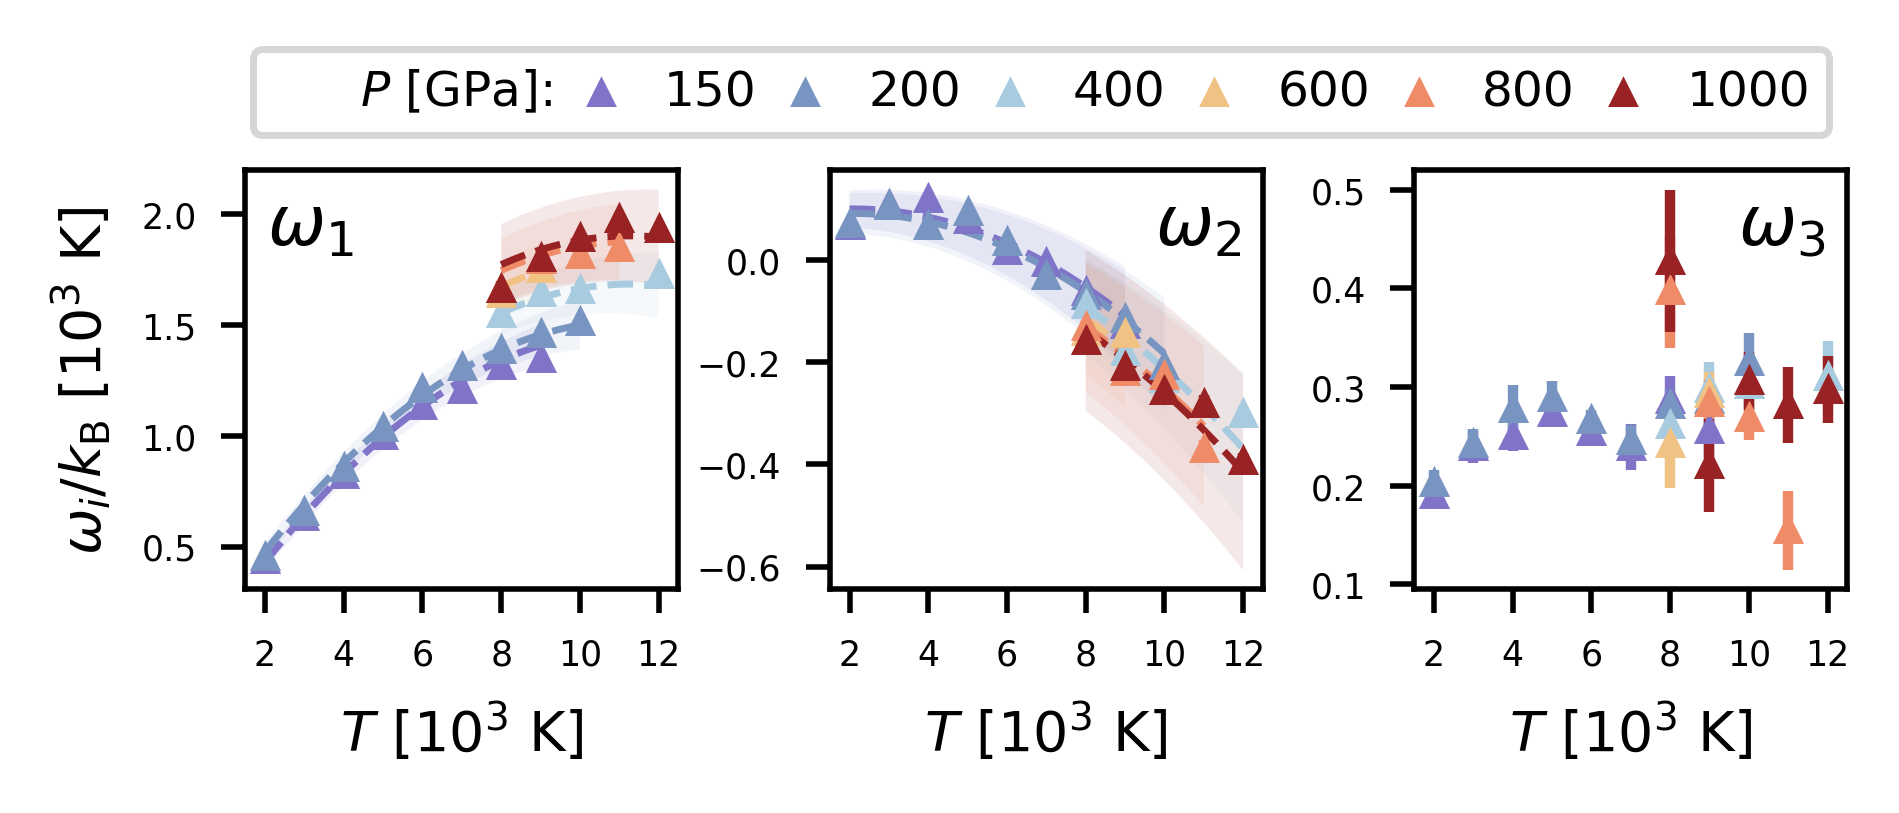

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# ==================== Placeholder / mock data section ====================
def extract_omega_data_at_pressure(dataset, pressure):
    mask = dataset[:, 0] == pressure
    P_data = dataset[mask, 0]
    T_data = dataset[mask, 1]
    omega_data_1st = dataset[mask, 2]
    omega_data_1st_error = dataset[mask, 3]
    omega_data_2nd = dataset[mask, 4]
    omega_data_2nd_error = dataset[mask, 5]
    omega_data_3rd = dataset[mask, 6]
    omega_data_3rd_error = dataset[mask, 7]
    
    return P_data, T_data, omega_data_1st, omega_data_1st_error, omega_data_2nd, omega_data_2nd_error, omega_data_3rd, omega_data_3rd_error

# =============================================================

# ===== 1. Data preparation: collect all data points =====
P_list = [150, 200, 400, 600, 800, 1000]

# Create lists to store all data
all_pressures, all_temps = [], []
all_omega1, all_err1 = [], []
all_omega2, all_err2 = [], []
all_omega3, all_err3 = [], []

for pressure in P_list:
    _, T, omega1, err1, omega2, err2, omega3, err3 = extract_omega_data_at_pressure(omega_fitted_dataset, pressure)
    
    # Append data points at current pressure to global lists
    all_pressures.extend([pressure / 100] * len(T))  # Normalized pressure
    all_temps.extend(T / 1000) # Use T/1000 as unit
    all_omega1.extend(omega1)
    all_err1.extend(err1)
    all_omega2.extend(omega2)
    all_err2.extend(err2)
    all_omega3.extend(omega3)
    all_err3.extend(err3)

# Convert lists to NumPy arrays
all_pressures = np.array(all_pressures)
all_temps = np.array(all_temps)
X_data = np.vstack((all_temps, all_pressures)) # Combine T and P as xdata for curve_fit

all_omega1, all_err1 = np.array(all_omega1), np.array(all_err1)
all_omega2, all_err2 = np.array(all_omega2), np.array(all_err2)
all_omega3, all_err3 = np.array(all_omega3), np.array(all_err3)

# ===== 2. Define global fitting models =====
def global_fit_model_omega1(X, a0, b1, b2, c1, c2):
    """
    w1: a0 + b1*T + b2*T^2 + c1*P + c2*P^2
    X: array containing T and P, shape=(2, N)
    """
    T, P = X
    return a0 + b1 * T + b2 * T**2 + c1 * P + c2 * P**2

def global_fit_model_omega2(X, a0, b1, b2, c1, c2):
    """
    w2: a0 + b1*T + b2*T^2 + c1*P + c2*P^2
    X: array containing T and P, shape=(2, N)
    """
    T, P = X
    return a0 + b1 * T + b2 * T**2 + c1 * P + c2 * P**2

def global_fit_model_omega3(X, a0, c1):
    """
    w3: a0 + c1 * P
    X: array containing T and P, shape=(2, N)
    """
    _, P = X
    return a0 + c1 * P

# ===== 3. Run global fitting =====
print("--- Global Fit Results ---")

# Global fit for Omega1
popt1, pcov1 = curve_fit(global_fit_model_omega1, X_data, all_omega1, sigma=all_err1, maxfev=10000)
perr1 = np.sqrt(np.diag(pcov1))

# Global fit for Omega2
popt2, pcov2 = curve_fit(global_fit_model_omega2, X_data, all_omega2, sigma=all_err2, maxfev=10000)
perr2 = np.sqrt(np.diag(pcov2))

# Global fit for Omega3 (pressure effect only)
popt3, pcov3 = curve_fit(global_fit_model_omega3, X_data, all_omega3, sigma=all_err3, maxfev=10000)
perr3 = np.sqrt(np.diag(pcov3))

# ===== Print fitted models =====
def print_model_with_params(model_name, formula, params, errors, param_names):
    print(f"\n{model_name}:")
    print(f"  Model: {formula}")
    for n, v, e in zip(param_names, params, errors):
        print(f"    {n} = {v:.6g} ± {e:.2g}")

print_model_with_params(
    "Omega1",
    "w(T, P) = a0 + b1*T + b2*T^2 + c1*P + c2*P^2",
    popt1, perr1,
    ["a0", "b1", "b2", "c1", "c2"]
)
print_model_with_params(
    "Omega2",
    "w(T, P) = a0 + b1*T + b2*T^2 + c1*P + c2*P^2",
    popt2, perr2,
    ["a0", "b1", "b2", "c1", "c2"]
)

print_model_with_params(
    "Omega3",
    "w(P) = a0 + c1*P",
    popt3, perr3,
    ["a0", "c1"]
)

font = {'family': 'serif', 'size': 8}
plt.rc('font', **font)
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['axes.titlesize'] = 8
matplotlib.rcParams['axes.labelsize'] = 8
matplotlib.rcParams['xtick.labelsize'] = 5
matplotlib.rcParams['ytick.labelsize'] = 5
matplotlib.rcParams['legend.fontsize'] = 7

# Set figure size: ~1/4 A4 width and compact height for subplots
A4_width_mm = 210  # A4 width (mm)
fig_width_mm = A4_width_mm * 0.5
fig_height_mm = A4_width_mm * 0.5 / 3.8

# Convert mm to inches (1 inch = 25.4 mm)
fig_width_inches = fig_width_mm / 25.4
fig_height_inches = fig_height_mm / 25.4

# ===== Adjust subplot layout =====
fig, axes = plt.subplots(1, 3, figsize=(fig_width_inches, fig_height_inches), 
                        gridspec_kw={'hspace': 0.00, 'wspace': 0.35},
                        dpi=500)
(ax1, ax2, ax3) = axes  # Unpack three subplots

# ===== Data visualization loop =====
color_P = ["#8074C8", "#7895C1", "#A8CBDF", "#F0C284", "#EF8B67","#992224"] 
size_symbol = 3

# --- Plot data points and global-fit curves for each pressure ---
for i, pressure in enumerate(P_list):
    # Extract raw data for plotting
    _, T_raw, o1_raw, e1_raw, o2_raw, e2_raw, o3_raw, e3_raw = extract_omega_data_at_pressure(omega_fitted_dataset, pressure)
    T_scaled = T_raw / 1000

    # Create temperature axis for smooth fitted curves
    T_line = np.linspace(T_scaled.min(), T_scaled.max(), 100)
    P_line = np.full_like(T_line, pressure / 100)  # Normalized pressure
    X_line = np.vstack((T_line, P_line))

    # Compute fitted curves using global-fit parameters
    omega1_fit_line = global_fit_model_omega1(X_line, *popt1)
    omega2_fit_line = global_fit_model_omega2(X_line, *popt2)
    omega3_fit_line = global_fit_model_omega3(X_line, *popt3)

    # Plot fitted curves and error bands
    ax1.plot(T_line, omega1_fit_line, color=color_P[i], ls="--", lw=1)
    ax2.plot(T_line, omega2_fit_line, color=color_P[i], ls="--", lw=1)
    
    # Compute error bands
    # Omega1: w1 = a0 + b1*T + b2*T^2 + c1*P + c2*P^2
    # ∂w/∂a0=1, ∂w/∂b1=T, ∂w/∂b2=T^2, ∂w/∂c1=P, ∂w/∂c2=P^2
    y1_err = np.sqrt(
        (np.sqrt(np.diag(pcov1)[0]))**2 +
        (T_line * np.sqrt(np.diag(pcov1)[1]))**2 +
        ((T_line**2) * np.sqrt(np.diag(pcov1)[2]))**2 +
        (P_line * np.sqrt(np.diag(pcov1)[3]))**2 +
        ((P_line**2) * np.sqrt(np.diag(pcov1)[4]))**2
    )
    # Omega2: w2 = a0 + b1*T + b2*T^2 + c1*P + c2*P^2
    # ∂w/∂a0=1, ∂w/∂b1=T, ∂w/∂b2=T^2, ∂w/∂c1=P, ∂w/∂c2=P^2
    y2_err = np.sqrt(
        (np.sqrt(np.diag(pcov2)[0]))**2 +
        (T_line * np.sqrt(np.diag(pcov2)[1]))**2 +
        ((T_line**2) * np.sqrt(np.diag(pcov2)[2]))**2 +
        (P_line * np.sqrt(np.diag(pcov2)[3]))**2 +
        ((P_line**2) * np.sqrt(np.diag(pcov2)[4]))**2
    )
    # Omega3: w3 = a0 + c1*P
    # ∂w/∂a0=1, ∂w/∂c1=P
    y3_err = np.sqrt(
        (np.sqrt(np.diag(pcov3)[0]))**2 +
        (P_line * np.sqrt(np.diag(pcov3)[1]))**2
    )
    
    # Draw error bands
    ax1.fill_between(T_line, omega1_fit_line - y1_err, omega1_fit_line + y1_err, color=color_P[i], alpha=0.1, edgecolor='none')
    ax2.fill_between(T_line, omega2_fit_line - y2_err, omega2_fit_line + y2_err, color=color_P[i], alpha=0.1, edgecolor='none')
    #ax3.fill_between(T_line, omega3_fit_line - y3_err, omega3_fit_line + y3_err, color=color_P[i], alpha=0.1, edgecolor='none')

    # Plot raw data points
    ax1.errorbar(T_scaled, o1_raw, yerr=e1_raw, fmt='^', ms=size_symbol, color=color_P[i], label=f'{pressure} GPa')
    ax2.errorbar(T_scaled, o2_raw, yerr=e2_raw, fmt='^', ms=size_symbol, color=color_P[i])
    ax3.errorbar(T_scaled, o3_raw, yerr=e3_raw, fmt='^', ms=size_symbol, color=color_P[i])
    #ax3.plot(T_line, omega3_fit_line, color=color_P[i], ls="--", lw=1)


# ===== Axes and legend styling (same as before) =====
# ===== Axis styling =====
text_fontsize = 10
ax1.text(0.05, 0.95, r'$\omega_{1}$',transform=ax1.transAxes,fontsize=text_fontsize,verticalalignment='top',horizontalalignment='left')

ax1.set_ylabel(r'$\omega_{i}/k_{\rm B}\ [10^3\ {\rm K}]$', fontsize=8)

ax2.text(0.95, 0.95, r'$\omega_{2}$',transform=ax2.transAxes,fontsize=text_fontsize,verticalalignment='top',horizontalalignment='right')

ax3.text(0.95, 0.95, r'$\omega_{3}$',transform=ax3.transAxes,fontsize=text_fontsize,verticalalignment='top',horizontalalignment='right')

for ax, label in zip([ax1, ax2, ax3],[r'$\omega_{1}$', r'$\omega_{2}$', r'$\omega_{3}$']):
    ax.set_xlabel('$T$ [$10^3$ K]', fontsize=8)
    ax.set_xticks([2, 4, 6, 8, 10, 12])
    # ax.set_ylabel(label, fontsize=8)

# ===== Unified legend configuration =====
from matplotlib.lines import Line2D
pressure_text = Line2D([], [], color='none', label='$P$ [GPa]:')

legend_elements = [plt.Line2D([0], [0], marker='^', color='w',label=f'{P}',markerfacecolor=color_P[i],markersize=6)for i, P in enumerate(P_list)]

all_legend_elements = [pressure_text] + legend_elements

from matplotlib.legend_handler import HandlerTuple

fig.legend(handles=all_legend_elements,loc='lower center',bbox_to_anchor=(0.51, 0.9),ncol=7,alignment='left',handlelength=1.0,columnspacing=0.5,handler_map={tuple: HandlerTuple(ndivide=None)})

ticks = ax1.get_yticks()
ax1.set_yticklabels([f'{tick:.1f}' for tick in ticks])

plt.show() 
